# Churn Prediction with keras model-1

## Purpose
This notebook aims to build and evaluate machine learning models, including traditional algorithms and a deep learning model, to predict customer churn based on various features from the 'Churn.csv' dataset. The process involves comprehensive data exploration, preprocessing, model training, and evaluation.


**Experiment Link** --> https://colab.research.google.com/drive/1pLb9cuTdJWwqPlA06FAIxxD2D__gvtGt?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/1AUY0ubWOSW5scrXMGJRKJR_HvBPuAfXU/view?usp=sharing

## 1. Setup and Data Loading
We begin by importing necessary libraries and loading the `Churn.csv` dataset into a pandas DataFrame. Following this, an initial exploration of the dataset is performed to understand its structure, check for missing values, duplicates, and basic statistical summaries.

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics  import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("/content/Churn.csv")

### 1.1 Initial Data Exploration
Displaying the first few rows, checking data types and non-null counts, examining the dataset's dimensions, summing null values, checking for duplicates, and viewing descriptive statistics provide a foundational understanding of the data.

In [ ]:
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


The `df.head()` output displays the first 5 rows of the DataFrame, providing a quick glance at the data structure and initial values across all columns.

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None

The `df.info()` output shows a summary of the DataFrame, including the number of entries, total columns, non-null counts for each column, data types, and memory usage. It indicates that there are 10,000 entries and no missing values across any of the columns.

In [ ]:
display(df.shape)

(10000, 14)

The `df.shape` output `(10000, 14)` confirms that the DataFrame has 10,000 rows and 14 columns.

In [ ]:
display(df.isnull().sum())

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


The `df.isnull().sum()` output shows that there are no missing values in any of the columns, with all sums being `0`.

In [ ]:
display(df.duplicated().sum())

np.int64(0)

The `df.duplicated().sum()` output `0` indicates that there are no duplicate rows in the DataFrame.

In [ ]:
display(df.describe())

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


The `df.describe()` output provides descriptive statistics for numerical columns, including count, mean, standard deviation, min, max, and quartile values. This helps in understanding the distribution and spread of numerical features.

## 2. Feature Engineering
In this section, we perform feature engineering by removing irrelevant columns that are not useful for model training, such as customer identifiers. The remaining features are then categorized into categorical and numerical types for further analysis.

In [ ]:
df.drop(['CustomerId','Surname','RowNumber'],axis=1,inplace=True)

This cell drops the 'CustomerId', 'Surname', and 'RowNumber' columns from the DataFrame `df` in-place, as they are not relevant for model training.

In [ ]:
cols_features=list(set(df.columns))

cat_feat=['IsActiveMember',
 'NumOfProducts',
 'Geography',
 'Gender',
 'Exited',
 'HasCrCard','Tenure']

num_feat=list(set(cols_features)-set(cat_feat))

print(f"Categorical Features: {cat_feat}")
print(f"Numerical Features: {num_feat}")

Categorical Features: ['IsActiveMember', 'NumOfProducts', 'Geography', 'Gender', 'Exited', 'HasCrCard', 'Tenure']
Numerical Features: ['Balance', 'EstimatedSalary', 'Age', 'CreditScore']


The output identifies and lists the categorical features as `['IsActiveMember', 'NumOfProducts', 'Geography', 'Gender', 'Exited', 'HasCrCard', 'Tenure']` and numerical features as `['Balance', 'EstimatedSalary', 'Age', 'CreditScore']` based on the specified criteria.

## 3. Exploratory Data Analysis (EDA)
This section involves analyzing the distributions and relationships within the data through univariate and bivariate analysis. Visualizations are used to gain insights into individual features and their interactions with the target variable 'Exited'.

### 3.1 Univariate Analysis
Bar plots are generated for categorical features to show their frequency distributions, while histograms are used for numerical features to visualize their value distributions.

Feature: IsActiveMember
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
IsActiveMember
1    51.51
0    48.49
Name: proportion, dtype: float64


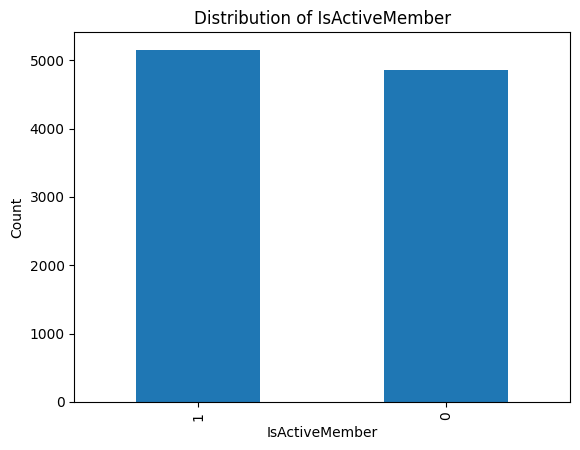

--------------------------------------------------
Feature: NumOfProducts
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
NumOfProducts
1    50.84
2    45.90
3     2.66
4     0.60
Name: proportion, dtype: float64


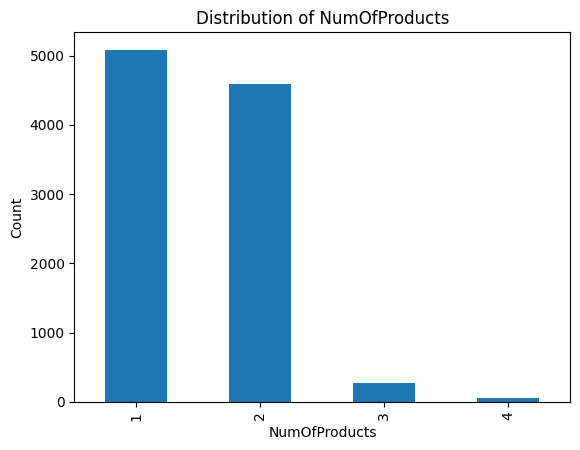

--------------------------------------------------
Feature: Geography
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64


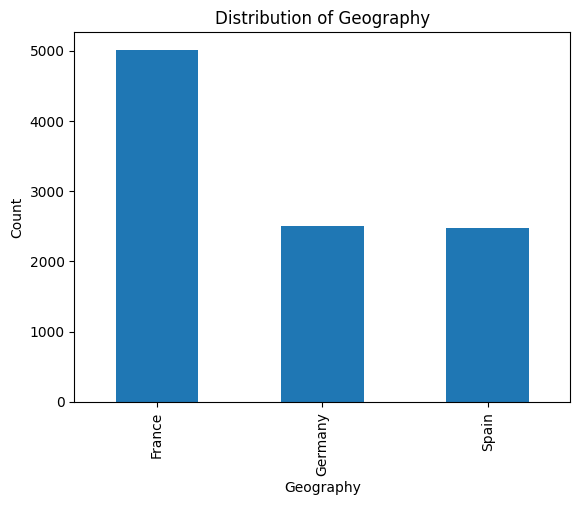

--------------------------------------------------
Feature: Gender
Gender
Male      5457
Female    4543
Name: count, dtype: int64
Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64


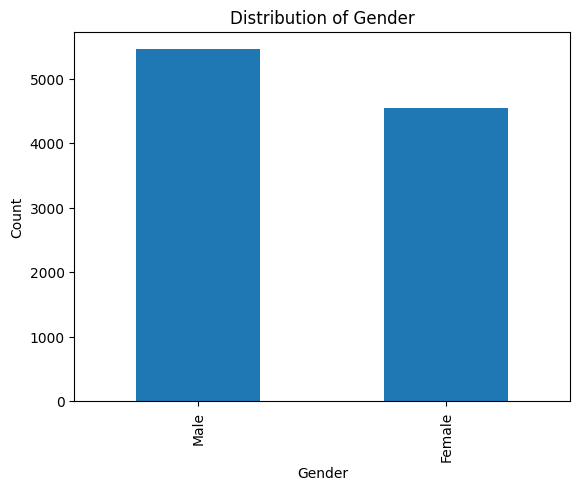

--------------------------------------------------
Feature: Exited
Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


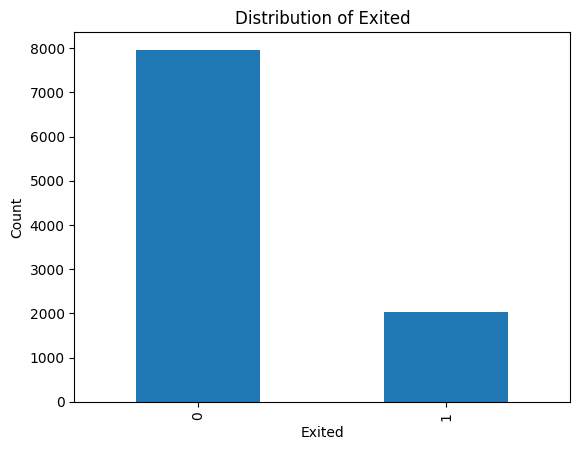

--------------------------------------------------
Feature: HasCrCard
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
HasCrCard
1    70.55
0    29.45
Name: proportion, dtype: float64


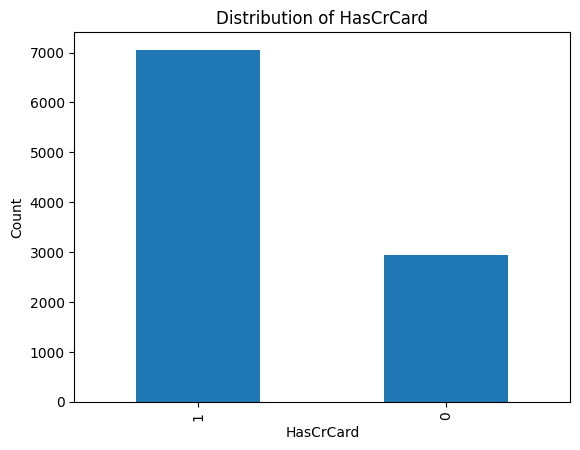

--------------------------------------------------
Feature: Tenure
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64
Tenure
2     10.48
1     10.35
7     10.28
8     10.25
5     10.12
3     10.09
4      9.89
9      9.84
6      9.67
10     4.90
0      4.13
Name: proportion, dtype: float64


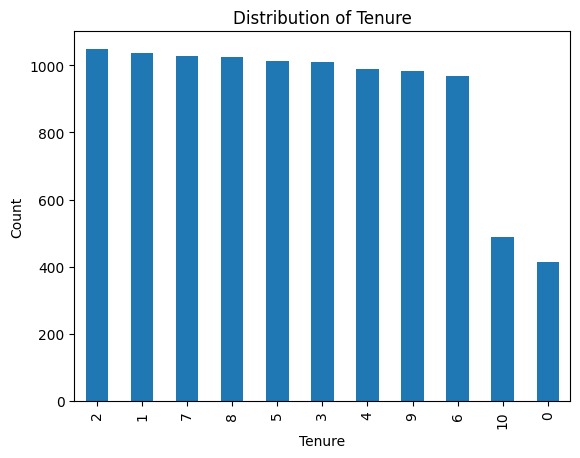

--------------------------------------------------
Feature: Balance


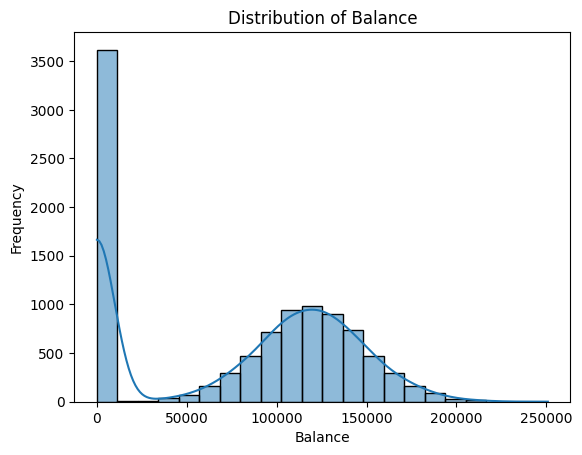

--------------------------------------------------
Feature: EstimatedSalary


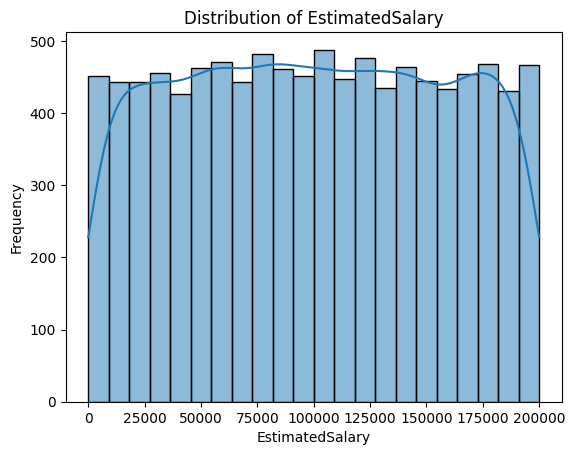

--------------------------------------------------
Feature: Age


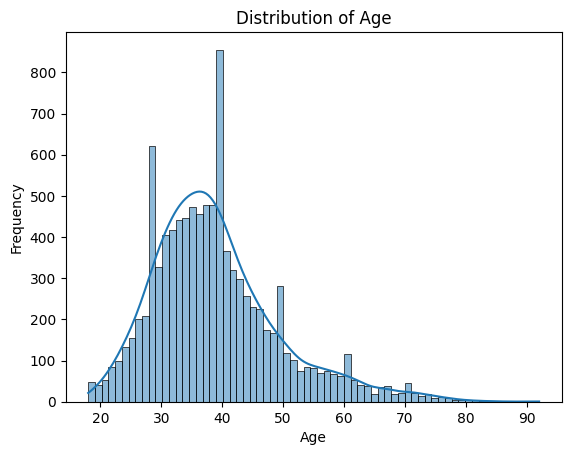

--------------------------------------------------
Feature: CreditScore


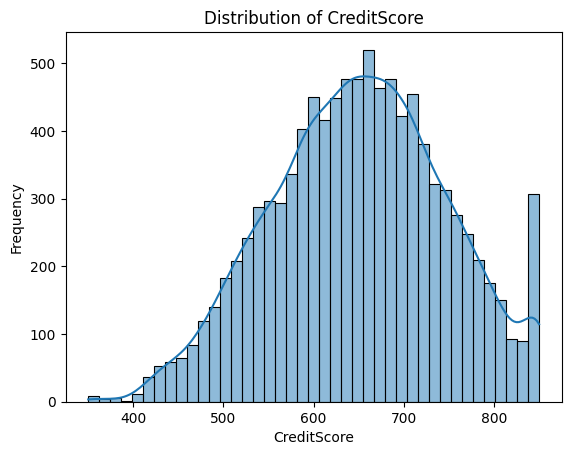

--------------------------------------------------


In [ ]:
for feat in cat_feat:
  print(f"Feature: {feat}")
  print(df[feat].value_counts())
  print(df[feat].value_counts(normalize=True)*100)
  df[feat].value_counts().plot.bar()
  plt.title(f'Distribution of {feat}')
  plt.ylabel('Count')
  plt.show()
  print("-"*50)

for feat in num_feat:
  print(f"Feature: {feat}")
  sns.histplot(df[feat], kde=True)
  plt.title(f'Distribution of {feat}')
  plt.xlabel(feat)
  plt.ylabel('Frequency')
  plt.show()
  print("-"*50)

The output of this cell displays bar plots for each categorical feature showing their frequency distribution, and histograms for each numerical feature to visualize their value distributions. Each plot is accompanied by value counts and normalized value percentages for categorical features, and a density estimation for numerical features, providing insights into their univariate characteristics.

### 3.2 Bivariate Analysis
Box plots illustrate the relationship between numerical features and the 'Exited' status. A correlation heatmap shows inter-relationships among numerical features. A pair plot visualizes pairwise relationships, and bar plots show the mean 'Exited' rate for each category of categorical features.

Balance


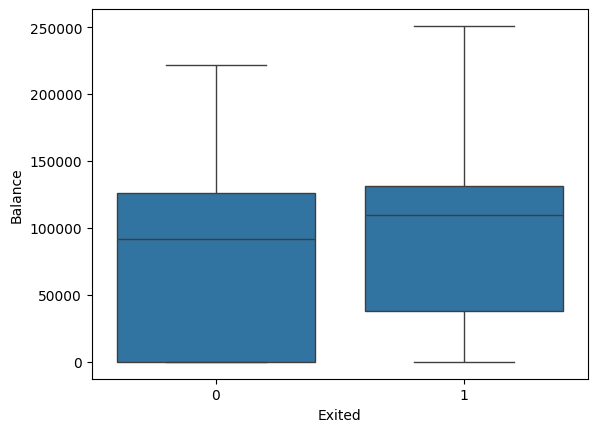

**************************************************
EstimatedSalary


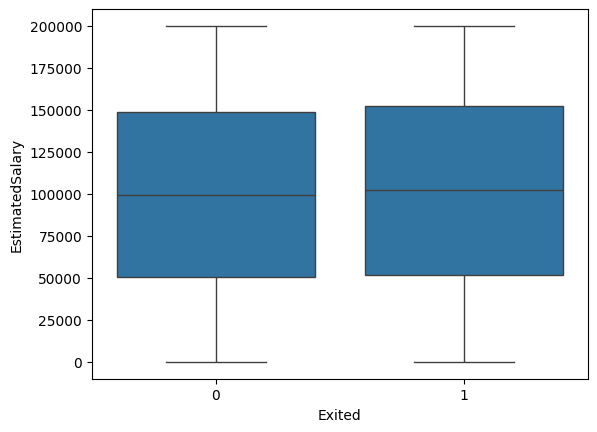

**************************************************
Age


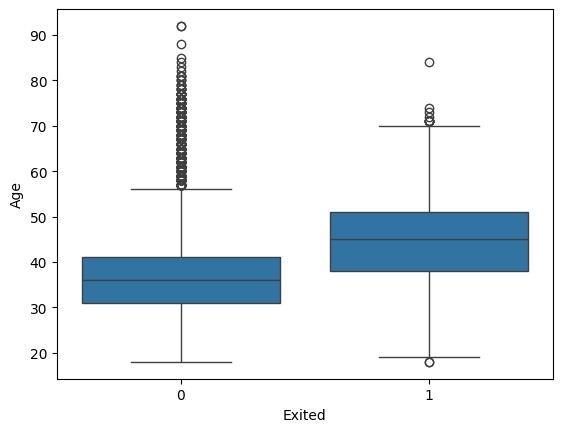

**************************************************
CreditScore


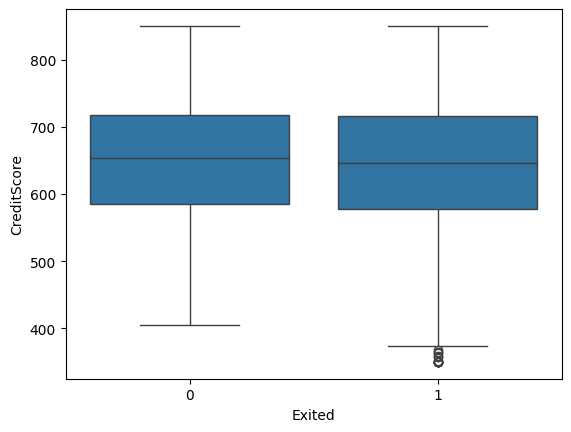

**************************************************


In [ ]:
# Bivariate Analysis
for feat in num_feat:
  print(feat)
  sns.boxplot(x='Exited',y=feat,data=df)
  plt.show()
  print("*"*50)

The output from this cell displays box plots for each numerical feature (`Balance`, `EstimatedSalary`, `Age`, `CreditScore`) against the 'Exited' (churn) status. These plots help to visualize how the distribution of each numerical feature differs between customers who churned (`Exited=1`) and those who did not (`Exited=0`).

<Axes: >

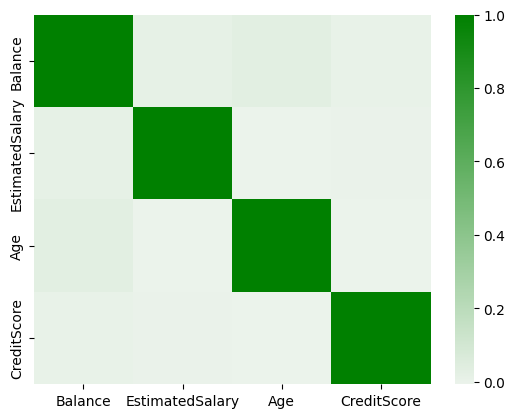

In [ ]:
cmap=sns.light_palette("green",as_cmap=True)
sns.heatmap(df[num_feat].corr(),cmap=cmap)

This cell generated a heatmap visualizing the correlation matrix of the numerical features. The `cmap=sns.light_palette("green",as_cmap=True)` sets a color scheme for better visual interpretation. The `Axes: >` output indicates that a matplotlib Axes object was created, which contains the heatmap.

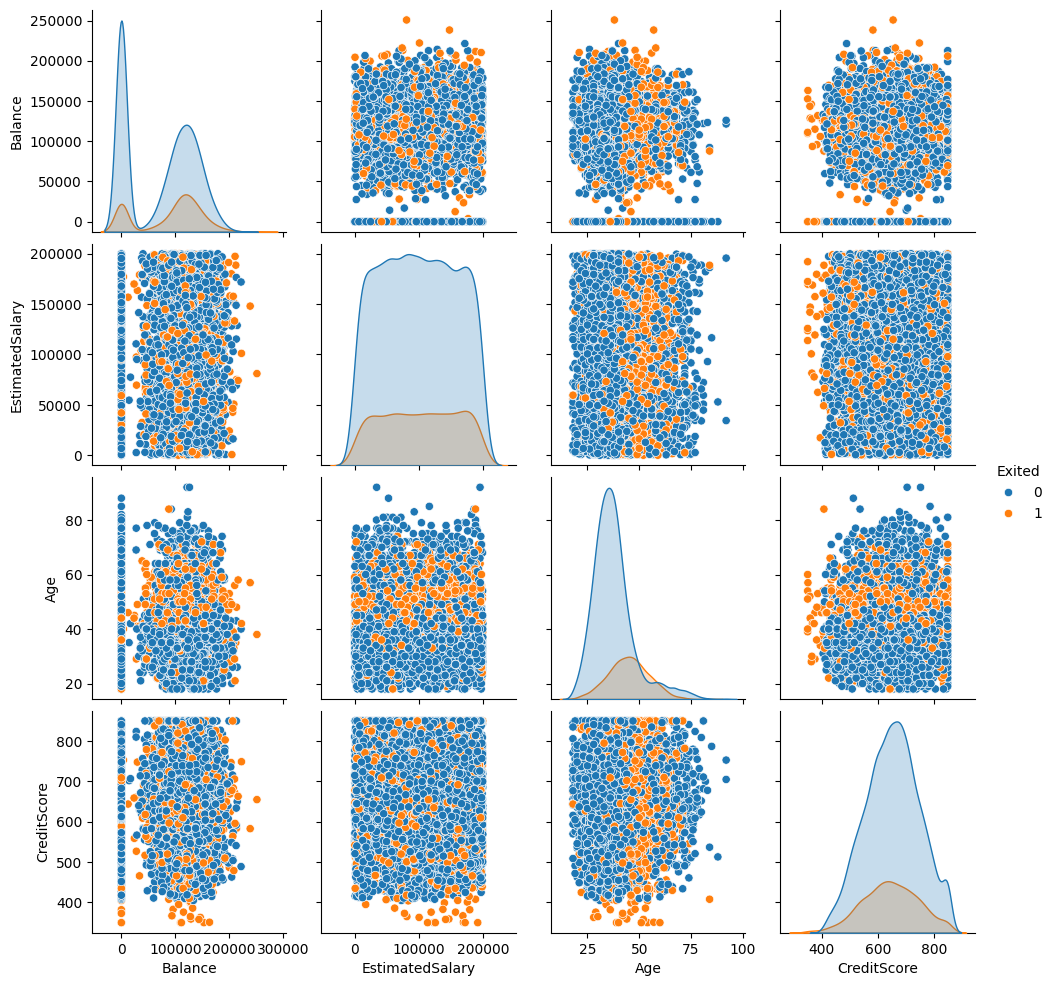

In [ ]:
sns.pairplot(df[num_feat +["Exited"]],hue='Exited')

This cell generated a pair plot of the numerical features along with the 'Exited' target variable, with different colors for churned vs. non-churned customers (`hue='Exited'`). The output `<seaborn.axisgrid.PairGrid at ...>` indicates the successful creation of the pair plot, which shows pairwise relationships between the specified features.

## 4. Baseline Models
Before building complex models, we define and evaluate several simple heuristic-based baseline models. These models provide a benchmark against which the performance of more sophisticated models can be compared. Different strategies are explored, such as predicting churn based on tenure, active member status, number of products, or a combination of these and other factors like age and geography.

In [ ]:
def base_model_0(row):
  return 0

def base_model(row):
  if row['Tenure']<3 and row['IsActiveMember']==0:
    return 1 # Churn
  else:
    return 0 # Not Churn

def base_model_2(row):
  if row['NumOfProducts']>2 :
    return 1
  else:
    return 0

def base_model_3(row):
  if (row['IsActiveMember'] == 0 and (row['Age'] > 40 or row['Geography'] == 'Germany')) or (row['NumOfProducts'] > 2):
    return 1 # Churn
  else:
    return 0 # Not Churn

def base_model_4(row):
  if row['Age']<18:
    return 1
  else:
    return 0

# Apply and evaluate various baseline models
print("--- Baseline Model 0: Always predict 0 ---")
df['base_prediction_0']=df.apply(base_model_0,axis=1)
print(classification_report(df['Exited'],df['base_prediction_0']))

print("--- Baseline Model 1: Tenure < 3 and IsActiveMember == 0 ---")
df['base_prediction']=df.apply(base_model,axis=1)
print(classification_report(df['Exited'],df['base_prediction']))

print("--- Baseline Model 2: NumOfProducts > 2 ---")
df['base_prediction_2']=df.apply(base_model_2,axis=1)
print(classification_report(df['Exited'],df['base_prediction_2']))

print("--- Baseline Model 3: Complex Heuristic ---")
df['base_prediction_3']=df.apply(base_model_3,axis=1)
print(classification_report(df['Exited'],df['base_prediction_3']))

print("--- Baseline Model 4: Age < 18 ---")
df['base_prediction_4']=df.apply(base_model_4,axis=1)
print(classification_report(df['Exited'],df['base_prediction_4']))

--- Baseline Model 0: Always predict 0 ---
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      7963
           1       0.00      0.00      0.00      2037

    accuracy                           0.80     10000
   macro avg       0.40      0.50      0.44     10000
weighted avg       0.63      0.80      0.71     10000

--- Baseline Model 1: Tenure < 3 and IsActiveMember == 0 ---
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      7963
           1       0.29      0.16      0.21      2037

    accuracy                           0.75     10000
   macro avg       0.55      0.53      0.53     10000
weighted avg       0.70      0.75      0.72     10000

--- Baseline Model 2: NumOfProducts > 2 ---
              precision    recall  f1-score   support

           0       0.82      0.99      0.90      7963
           1       0.86      0.14      0.24      2037

    accuracy                      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89      7963
           1       0.00      0.00      0.00      2037

    accuracy                           0.80     10000
   macro avg       0.40      0.50      0.44     10000
weighted avg       0.63      0.80      0.71     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


This cell defined and evaluated five different baseline models. For each model, it printed a classification report including precision, recall, f1-score, and support for both churned (1) and non-churned (0) classes, along with overall accuracy, macro average, and weighted average. This provides a detailed performance overview for each simple heuristic. Notably, for Baseline Model 0 and 4, which predict 0 for all cases, the precision for class 1 is undefined, resulting in `UndefinedMetricWarning`.

## 5. Data Preprocessing for Machine Learning
This section prepares the data for machine learning models. It involves removing the baseline prediction columns, encoding categorical features using `LabelEncoder`, scaling numerical features using `StandardScaler`, and finally splitting the dataset into training and testing sets.

In [ ]:
# Dropping baseline prediction columns
df_2 = df.drop(['base_prediction',  'base_prediction_0',
   'base_prediction_2',
   'base_prediction_3',
   'base_prediction_4'],axis=1)

This cell successfully dropped the temporary baseline prediction columns (`'base_prediction'`, `'base_prediction_0'`, etc.) from the DataFrame, resulting in a cleaner `df_2` ready for further processing.

### 5.1 Label Encoding Categorical Features
Categorical features (object type) are converted into numerical representations using `LabelEncoder`.

In [ ]:
le = LabelEncoder()

for i in df_2:
    if df_2[i].dtype == 'object':
     df_2[i] = le.fit_transform(df_2[i])

display(df_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


None

The `df_2.info()` output shows the updated DataFrame after label encoding. All previously 'object' type columns ('Geography', 'Gender') have been successfully converted to 'int64', indicating that `LabelEncoder` has been applied to transform categorical features into numerical representations. The DataFrame now contains only numerical data types suitable for machine learning models.

### 5.2 Feature Scaling and Train-Test Split
Features (`x`) are separated from the target variable (`y`). Numerical features are then scaled using `StandardScaler` to normalize their ranges. Finally, the data is split into training and testing sets to evaluate model performance on unseen data.

In [ ]:
x = df_2.drop(['Exited'],axis=1)
y = df_2['Exited']

print(f"Shape of features (x): {x.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (x): (10000, 10)
Shape of target (y): (10000,)


The output confirms the shapes of the feature set `x` as `(10000, 10)` (10,000 samples, 10 features) and the target variable `y` as `(10000,)` (10,000 samples for the target), indicating successful separation of features and target.

In [ ]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

print(f"Shape of scaled features (x): {x.shape}")

Shape of scaled features (x): (10000, 10)


The output confirms that the features in `x` have been successfully scaled using `StandardScaler`, and the shape remains `(10000, 10)`, meaning the scaling operation did not alter the dimensions of the feature set.

In [ ]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (7000, 10), X_test shape: (3000, 10), y_train shape: (7000,), y_test shape: (3000,)


The output displays the shapes of the resulting training and testing sets after the `train_test_split`. `X_train` is `(7000, 10)`, `X_test` is `(3000, 10)`, `y_train` is `(7000,)`, and `y_test` is `(3000,)`. This indicates that 70% of the data was allocated for training and 30% for testing.

## 6. Traditional Machine Learning Models
In this section, we train and evaluate three common traditional machine learning models: Logistic Regression, Decision Tree Classifier, and Random Forest Classifier. Each model's performance is assessed using a classification report, providing metrics like precision, recall, and F1-score.

### 6.1 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression()
log_reg.fit(X_train,y_train)

y_pred_lr=log_reg.predict(X_test)
print("Classification Report for Logistic Regression:")
print(classification_report(y_test,y_pred_lr))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      2416
           1       0.60      0.17      0.27       584

    accuracy                           0.82      3000
   macro avg       0.72      0.57      0.58      3000
weighted avg       0.79      0.82      0.77      3000



The classification report for Logistic Regression shows a precision of 0.60, recall of 0.17, and an F1-score of 0.27 for class 1 (churned customers). For class 0, precision is 0.83, recall is 0.97, and F1-score is 0.90. The overall accuracy of the model is 0.82.

### 6.2 Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=0)
dt.fit(X_train,y_train)

y_pred_dt=dt.predict(X_test)
print("Classification Report for Decision Tree Classifier:")
print(classification_report(y_test,y_pred_dt))

Classification Report for Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2416
           1       0.47      0.50      0.49       584

    accuracy                           0.79      3000
   macro avg       0.67      0.68      0.68      3000
weighted avg       0.80      0.79      0.80      3000



The classification report for Decision Tree Classifier shows a precision of 0.47, recall of 0.50, and an F1-score of 0.49 for class 1. For class 0, precision is 0.88, recall is 0.86, and F1-score is 0.87. The overall accuracy of the model is 0.79.

### 6.3 Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(class_weight='balanced',n_estimators=50,random_state=23)
rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)
print("Classification Report for Random Forest Classifier:")
print(classification_report(y_test,y_pred_rf))

Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2416
           1       0.78      0.42      0.55       584

    accuracy                           0.86      3000
   macro avg       0.83      0.70      0.73      3000
weighted avg       0.86      0.86      0.85      3000



The classification report for Random Forest Classifier shows a precision of 0.78, recall of 0.42, and an F1-score of 0.55 for class 1. For class 0, precision is 0.87, recall is 0.97, and F1-score is 0.92. The overall accuracy of the model is 0.86, indicating better performance compared to Logistic Regression and Decision Tree for identifying churn.

## 7. Deep Learning Model (Keras)
This section implements a neural network using Keras for churn prediction. The model architecture is defined with `Dense` layers and `Dropout` layers for regularization. The model is then compiled, trained with early stopping, and its training history (accuracy and loss) is plotted.

In [ ]:
# Imports for Keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import optimizers
from keras import metrics
from keras.callbacks import EarlyStopping

This cell successfully imported all necessary modules from `keras` and `sklearn` for building, training, and evaluating the deep learning model. There is no direct output from these import statements.

### 7.1 Model Architecture
A sequential model is built with multiple `Dense` layers using 'relu' activation and a final 'sigmoid' output layer for binary classification. `Dropout` layers are added between dense layers to prevent overfitting.

In [ ]:
classifier = Sequential()
classifier.add(Dense(64,activation='relu',input_dim=X_train.shape[1])) # Hidden Layer-1
classifier.add(Dropout(0.3)) # Adding Dropout for regularization
classifier.add(Dense(32,activation='relu')) # Hidden Layer-2
classifier.add(Dropout(0.3)) # Adding Dropout for regularization
classifier.add(Dense(16,activation='relu')) # Added Hidden Layer-3
classifier.add(Dense(1,activation='sigmoid')) # Output Layer
classifier.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

The `classifier.summary()` output details the architecture of the Keras Sequential model. It lists each layer (Dense, Dropout) with its output shape and the number of trainable parameters. The model has 3 Dense layers with 64, 32, and 16 units respectively, and a final Dense output layer with 1 unit (sigmoid activation). There are 8,849 total trainable parameters. A `UserWarning` regarding `input_dim` is also present, suggesting an alternative way to define the input layer.

### 7.2 Model Compilation and Training
The model is compiled with the 'adam' optimizer, 'binary_crossentropy' loss function, and 'accuracy' metric. `EarlyStopping` is implemented to halt training if validation loss does not improve for a specified number of epochs, restoring the best weights.

In [ ]:
# Compile the model
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

This cell compiled the Keras model with `adam` optimizer, `binary_crossentropy` loss, and `accuracy` metric. There is no direct output, indicating that the compilation was successful and the model is ready for training.

In [ ]:
# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history=classifier.fit(X_train,y_train,batch_size=32,epochs=100, validation_data=(X_test,y_test), callbacks=[early_stopping])

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7907 - loss: 0.4975 - val_accuracy: 0.8093 - val_loss: 0.4234
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8016 - loss: 0.4497 - val_accuracy: 0.8410 - val_loss: 0.4030
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8189 - loss: 0.4223 - val_accuracy: 0.8570 - val_loss: 0.3700
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8300 - loss: 0.4040 - val_accuracy: 0.8590 - val_loss: 0.3579
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8397 - loss: 0.3892 - val_accuracy: 0.8613 - val_loss: 0.3509
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8376 - loss: 0.3857 - val_accuracy: 0.8657 - val_loss: 0.3479
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8431 - loss: 0.3792 - val_accuracy: 0.8633 - val_loss: 0.3504
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8449 - loss: 0.3789 - val_accu

The training output shows the progress of the deep learning model over 54 epochs (due to early stopping). For each epoch, it displays the loss, accuracy, validation loss (`val_loss`), and validation accuracy (`val_accuracy`). The model's training stopped at epoch 54 because the `val_loss` did not improve for 10 consecutive epochs, and the best weights were restored from epoch 49, where `val_loss` was approximately 0.3351 and `val_accuracy` was 0.8630.

### 7.3 Training History Visualization
The plots below show the training and validation accuracy and loss over epochs, helping to visualize model convergence and identify potential overfitting.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


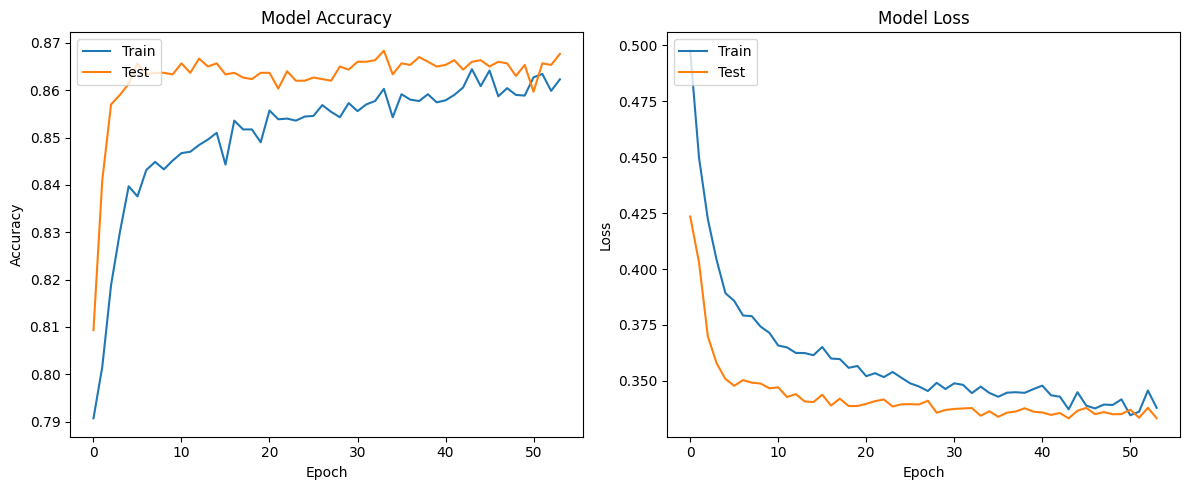

In [ ]:
# List all data in history
print(history.history.keys())

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.tight_layout()
plt.show()

The output first lists the keys available in the `history` object: `['accuracy', 'loss', 'val_accuracy', 'val_loss']`. Following this, two plots are displayed: one showing 'Model Accuracy' (training and validation accuracy over epochs) and another showing 'Model Loss' (training and validation loss over epochs). These plots visually represent the model's learning progress and help identify potential overfitting or underfitting.

## 8. Deep Learning Model Evaluation
This section evaluates the trained deep learning model by making predictions on the test set, computing the ROC-AUC score, plotting the ROC curve, and generating a classification report based on a defined threshold.

### 8.1 Predictions

In [ ]:
y_pred_dl=classifier.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


This cell generated predictions (`y_pred_dl`) on the `X_test` dataset using the trained deep learning model. The output `94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step` indicates the progress of the prediction process over the test batches.

### 8.2 ROC-AUC Curve
The Receiver Operating Characteristic (ROC) curve and Area Under the Curve (AUC) are used to assess the model's ability to distinguish between classes.

ROC-AUC Score: 0.8545704152680758


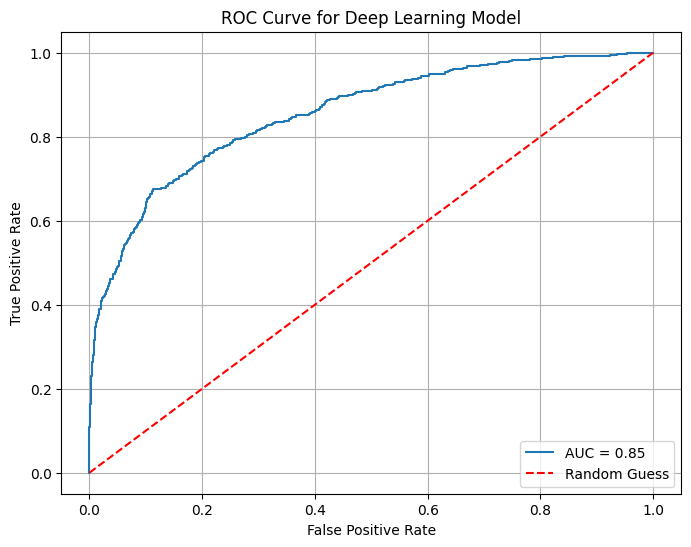

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_dl)
roc_auc = auc(fpr, tpr)
print(f"ROC-AUC Score: {roc_auc}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"r--", label="Random Guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Deep Learning Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The output provides the ROC-AUC score for the deep learning model, which is approximately `0.8546`. Additionally, a plot of the ROC curve is displayed, illustrating the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR) at various threshold settings. The curve shows the model's ability to distinguish between classes, with an AUC value indicating good performance (0.85 indicates a strong ability to separate positive and negative classes).

### 8.3 Classification Report
Predictions are converted to binary classes using a threshold (0.6 in this case), and a classification report is generated to show precision, recall, and F1-score.

In [ ]:
y_pred_dl1=[]
for i in y_pred_dl:
  if i>0.6:
    y_pred_dl1.append(1)
  else:
    y_pred_dl1.append(0)

print("Classification Report for Deep Learning Model (Threshold > 0.6):")
print(classification_report(y_test,y_pred_dl1))

Classification Report for Deep Learning Model (Threshold > 0.6):
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      2416
           1       0.83      0.39      0.53       584

    accuracy                           0.87      3000
   macro avg       0.85      0.68      0.73      3000
weighted avg       0.86      0.87      0.85      3000



The classification report for the deep learning model, with predictions binarized using a threshold of 0.6, shows a precision of 0.83, recall of 0.39, and F1-score of 0.53 for class 1 (churned customers). For class 0, precision is 0.87, recall is 0.98, and F1-score is 0.92. The overall accuracy is 0.87. This report highlights the model's performance in terms of correctly identifying both churned and non-churned customers at the chosen threshold.